In [108]:
import vietocr
from vietocr.tool.predictor import Predictor
from PIL import Image
import matplotlib.pyplot as plt
from vietocr.tool.config import Cfg
import cv2
import numpy as np
from skimage import io, color, filters


In [109]:
import numpy as np
from PIL import Image

def crop_to_text(img, padding=5):
    # 1. Chuyển về ảnh xám (Thay thế .convert('L'))
    if len(img.shape) == 3: # Nếu là ảnh màu
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # 2. Tạo ảnh nhị phân (Threshold)
    # Tìm các pixel tối (mực) trên nền sáng
    _, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    
    # 3. Tìm tọa độ của các pixel mực
    coords = cv2.findNonZero(binary)
    
    if coords is None:
        return img
        
    # Tìm khung bao quanh (x, y, w, h)
    x, y, w, h = cv2.boundingRect(coords)
    
    # 4. Thêm padding và tính toán vị trí cắt
    y_min = max(0, y - padding)
    y_max = min(img.shape[0], y + h + padding)
    x_min = max(0, x - padding)
    x_max = min(img.shape[1], x + w + padding)
    
    # 5. Cắt ảnh bằng NumPy Slicing (Thay thế .crop)
    return img[y_min:y_max, x_min:x_max]



In [110]:
def adaptive_resize_pad(img_np, target_h=50, target_w=512):
    h, w = img_np.shape[:2]
    
    # 1. Tính toán width dựa trên target_h
    new_w = int(w * (target_h / h))
    
    # 2. Nếu width quá lớn so với model (ví dụ > 512), 
    # lúc này mới bắt buộc phải bóp width lại
    if new_w > target_w:
        resized = cv2.resize(img_np, (target_w, target_h), interpolation=cv2.INTER_AREA)
        new_w = target_w
    else:
        # Nếu width nhỏ, resize giữ đúng tỷ lệ để nét chữ to rõ
        resized = cv2.resize(img_np, (new_w, target_h), interpolation=cv2.INTER_AREA)

    # 3. Padding lề phải bằng màu trắng (255) để đạt đúng 512px
    pad_right = target_w - new_w
    final_img = cv2.copyMakeBorder(resized, 0, 0, 0, pad_right, 
                                   cv2.BORDER_CONSTANT, value=255)
    
    return final_img

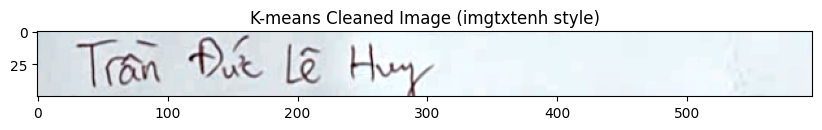

In [111]:

input_file = 'results/crops/ho_va_ten_refined.png'
#input_file = "D:\OCR\images\image2.png"
crop_img = cv2.imread(input_file)
#crop_img = adaptive_resize_pad(crop_img)
#crop_img = crop_to_text(crop_img)
plt.figure(figsize=(10, 5))
plt.imshow(crop_img, cmap='gray')
plt.title("K-means Cleaned Image (imgtxtenh style)")
plt.show()

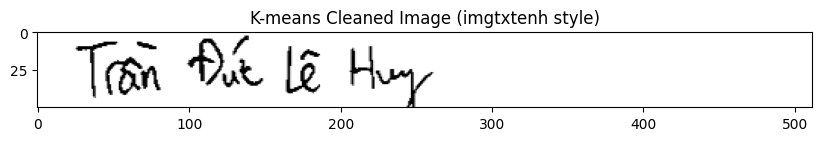

In [112]:
# 1. K-means clustering (Loại bỏ background y hệt imgtxtenh)
# Phương pháp này phân cụm pixel thành 2 nhóm: Chữ (fg) và Nền (bg)
def kmeans_binarize(img):
    if img is None:
        return None
    
    # 1. Kiểm tra nếu ảnh là ảnh màu thì chuyển sang xám
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Chuyển dữ liệu về float32 cho K-means
    pixel_values = gray.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)
    
    # Chạy K-means (K=2)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 2
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Xác định cụm nào là nền (sáng hơn)
    centers = np.uint8(centers)
    if centers[0] > centers[1]:
        bg_label, fg_label = 0, 1
    else:
        bg_label, fg_label = 1, 0
        
    # Tạo ảnh kết quả: Nền=255, Chữ=0
    res = np.zeros_like(labels, dtype=np.uint8)
    res[labels == bg_label] = 255
    res[labels == fg_label] = 0
    
    return res.reshape(gray.shape)

# Thực hiện làm sạch ảnh


cleaned_img_np = kmeans_binarize(crop_img)
cleaned_img_np = adaptive_resize_pad(cleaned_img_np)

if cleaned_img_np is not None:
    # CHUYỂN ĐỔI SANG PIL IMAGE ĐỂ VIETOCR XỬ LÝ (Khắc phục lỗi AttributeError)
    cleaned_img_pil = Image.fromarray(cleaned_img_np).convert('RGB')
    cleaned_img_pil.save('output.png')

    # Hiển thị kết quả làm sạch
    plt.figure(figsize=(10, 5))
    plt.imshow(cleaned_img_np, cmap='gray')
    plt.title("K-means Cleaned Image (imgtxtenh style)")
    plt.show()
else:
    print(f"Error: Could not read {input_file}")


In [113]:
config = Cfg.load_config_from_name('vgg_seq2seq')
config['weights'] = './seq2seqocr2.pth'
config['cnn']['pretrained']=False
config['predictor']['beamsearch'] = True
config['device'] = 'cpu'

detector = Predictor(config)


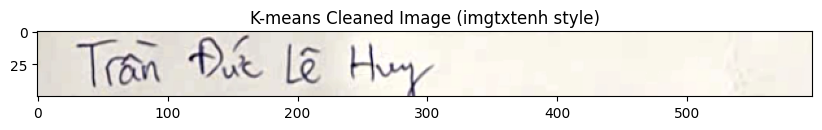

Kết quả OCR: Trần Đức Lê Huy :...
Kết quả OCR: Trần Đức Lê Hung.


In [114]:
# Dự đoán kết quả OCR từ ảnh đã được làm sạch
if 'cleaned_img_pil' in locals():
    # Crop bỏ khoảng trắng thừa
    #cropped_img = crop_to_text(cleaned_img_pil)

    # Hiển thị kết quả làm sạch
    
    img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    plt.figure(figsize=(10, 5))
    plt.imshow(img_pil, cmap='gray')
    plt.title("K-means Cleaned Image (imgtxtenh style)")
    plt.show()
    s = detector.predict(img_pil)
    s2 = detector.predict(cleaned_img_pil)
    print("Kết quả OCR:", s)
    print("Kết quả OCR:", s2)

else:
    print("Vui lòng chạy cell binarization trước.")


In [115]:
def clean_output(text):
    # loại bỏ lặp từ vô nghĩa cuối câu
    words = text.split()
    
    if len(words) > 1 and words[-1] == words[-2]:
        words = words[:-1]
    
    return " ".join(words)

print("Kết quả OCR:", clean_output(s))

Kết quả OCR: Trần Đức Lê Huy :...


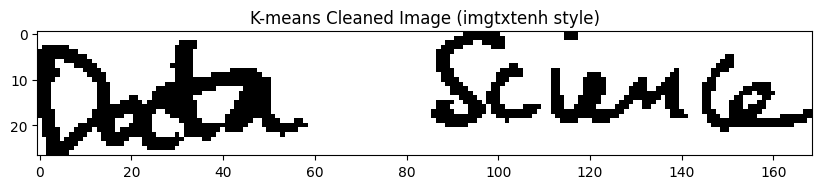

Kết quả OCR: Trần Đức Lê Hung.
Kết quả OCR: Biểniềm trai.


In [116]:
import cv2
import numpy as np
from vietocr.loader.dataloader import OCRDataset

def crop_to_text(img, padding=3):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)

    return img[y:y+h, x:x+w]

import cv2
import numpy as np

def kmeans_binarize(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    pixel_values = gray.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, 2, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)

    # cluster sáng = background
    if centers[0] > centers[1]:
        bg_label, fg_label = 0, 1
    else:
        bg_label, fg_label = 1, 0

    res = np.zeros_like(labels, dtype=np.uint8)
    res[labels == bg_label] = 255
    res[labels == fg_label] = 0

    return res.reshape(gray.shape)

from PIL import Image

from PIL import Image
import cv2
import numpy as np

def preprocess_for_predict(img_path):
    # 1. Đọc ảnh
    img = cv2.imread(img_path)
    if img is None: 
        print(f"Không thể đọc ảnh tại: {img_path}")
        return None
    
    # 2. Crop vùng có chữ
    img = crop_to_text(img)
    
    # 3. Nhị phân hóa bằng KMeans
    img = kmeans_binarize(img) # Kết quả là ảnh xám (H, W) kiểu uint8

    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap='gray')
    plt.title("K-means Cleaned Image (imgtxtenh style)")
    plt.show()
    
    
    # 4. Resize giữ nguyên tỷ lệ (giả sử model yêu cầu height 32)
    h, w = img.shape
    image_height = 32
    new_w = int(w * (image_height / h))
    img = cv2.resize(img, (new_w, image_height))
    
    # 5. QUAN TRỌNG: Chuyển về định dạng PIL RGB chuẩn
    # Không transpose, không chia 255.0 ở bước này
    if len(img.shape) == 2: # Nếu là ảnh xám
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
    return Image.fromarray(img_rgb)

input_file = 'crops/mon_refined.png'

# Khởi tạo model (nên để bên ngoài vòng lặp nếu xử lý nhiều ảnh)
config = Cfg.load_config_from_name('vgg_seq2seq')
config['weights'] = './seq2seqocr2.pth'
config['cnn']['pretrained'] = False
config['device'] = 'cpu' # Hoặc 'cuda' nếu có GPU
config['predictor']['beamsearch'] = True
detector = Predictor(config)

# Xử lý ảnh
img_pil = preprocess_for_predict(input_file)

if img_pil is not None:
    # Dự đoán
    s4 = detector.predict(img_pil)
    s3 = detector.predict(cleaned_img_pil)
    print("Kết quả OCR:", s3)
    print("Kết quả OCR:", s4)